# KNN Live Coding Session (Iris Classification)

**A) PRE-WRITTEN Intro**

K-Nearest Neighbors (KNN) is a **lazy learning** algorithm:
- It does almost no work during "training" (it mainly stores examples).
- Most work happens at **prediction time** (distance checks to training points).

In this notebook we build KNN **from scratch** using plain Python lists/loops:
- Train/test split
- Min-max normalization
- Manhattan distance
- Neighbor selection + majority vote with deterministic tie-break
- Accuracy evaluation
- k sweep (1 to 31, odd k values) + plot

Cells are labeled either **PRE-WRITTEN** or **LIVE CODING**.

In [1]:
# PRE-WRITTEN
import random
import math
from sklearn.datasets import load_iris, make_regression

SEED = 42

## Environment check


In [2]:
# PRE-WRITTEN
import sys
import sklearn
import matplotlib
import matplotlib.pyplot as plt

print("Python executable:", sys.executable)
print("Python version:", sys.version.split()[0])
print("sklearn.__version__:", sklearn.__version__)
print("matplotlib.__version__:", matplotlib.__version__)
print("Import test: sklearn.datasets and matplotlib.pyplot OK")


Python executable: /Users/nino/ML/.venv/bin/python
Python version: 3.14.0
sklearn.__version__: 1.8.0
matplotlib.__version__: 3.10.8
Import test: sklearn.datasets and matplotlib.pyplot OK


In [3]:
# PRE-WRITTEN
iris = load_iris()
X = iris.data.tolist()
y = iris.target.tolist()

print("Dataset size:", len(X))
print("Num features:", len(X[0]))
print("Unique classes:", sorted(set(y)))
print("First row (raw):", X[0])
print("First label:", y[0])

Dataset size: 150
Num features: 4
Unique classes: [0, 1, 2]
First row (raw): [5.1, 3.5, 1.4, 0.2]
First label: 0


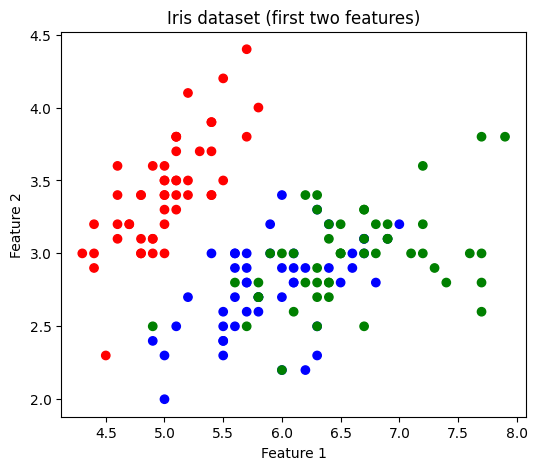

In [4]:
# PRE-WRITTEN
# VISUALIZATION

feature_1 = [row[0] for row in X]
feature_2 = [row[1] for row in X]

colors = []
for label in y:
    if label == 0:
        colors.append("red")
    elif label == 1:
        colors.append("blue")
    else:
        colors.append("green")

plt.figure(figsize=(6,5))
plt.scatter(feature_1, feature_2, c=colors)
plt.title("Iris dataset (first two features)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## D) LIVE CODING Utilities

Implement these core functions from scratch.

In [8]:
# LIVE CODING
def train_test_split_py(X, y, test_size=0.3, seed=SEED):
    """
    Split X and y into train/test parts using shuffled indices.

    Inputs:
    - X: list of feature rows
    - y: list of labels
    - test_size: fraction of rows for test set
    - seed: random seed for reproducible shuffling

    Returns:
    - X_train, X_test, y_train, y_test (all Python lists)

    TODO:
    
    - Create a list of indices [0, 1, ..., n-1]
    - Seed + shuffle indices
    - Use first chunk for test and remaining for train
    - Build and return the four lists
    """
    raise NotImplementedError("TODO: implement train_test_split_py")

**CHECK (after implementation):**
- For Iris with `test_size=0.3`, you should get `105` train and `45` test rows.
- Labels should have matching lengths with feature rows.

In [ ]:
# Quick sanity check
X_train, X_test, y_train, y_test = train_test_split_py(X, y, test_size=0.3, seed=SEED)
print("len(X_train):", len(X_train))
print("len(X_test):", len(X_test))
print("len(y_train):", len(y_train))
print("len(y_test):", len(y_test))
print("train lengths match:", len(X_train) == len(y_train))
print("test lengths match:", len(X_test) == len(y_test))


In [ ]:
# LIVE CODING
def minmax_fit(X_train):
    """
    Compute per-feature mins and maxs from training data only.

    Inputs:
    - X_train: list of feature rows

    Returns:
    - mins: list of minimum value per feature
    - maxs: list of maximum value per feature

    TODO:
    - Initialize mins/maxs from the first training row
    - Loop through all rows and update per-feature min/max
    - Return mins and maxs
    """
    raise NotImplementedError("TODO: implement minmax_fit")

**CHECK (after implementation):**
- `mins` and `maxs` should each have length `4` for Iris.
- Each `mins[j] <= maxs[j]` for every feature index `j`.

In [ ]:
# Quick sanity check
mins, maxs = minmax_fit(X_train)
print("mins:", mins)
print("maxs:", maxs)
print("len(mins):", len(mins))
print("len(maxs):", len(maxs))


In [ ]:
# LIVE CODING
def minmax_transform(X, mins, maxs):
    """
    Scale features to [0, 1] using mins and maxs.

    Inputs:
    - X: rows to transform
    - mins, maxs: per-feature scaling stats from training set

    Returns:
    - X_scaled: transformed rows

    TODO:
    - For each row and feature, apply (value - min) / (max - min)
    - If max == min, append 0.0 for that feature
    - Build and return a new scaled list of rows
    """
    raise NotImplementedError("TODO: implement minmax_transform")

**CHECK (after implementation):**
- Scaled values should be between `0` and `1` (inclusive).
- The first training row before/after scaling should clearly change magnitude.

In [ ]:
# Quick sanity check
X_train_scaled = minmax_transform(X_train, mins, maxs)
print("first raw train row:", X_train[0])
print("first scaled train row:", X_train_scaled[0])
print("global scaled min:", min(min(row) for row in X_train_scaled))
print("global scaled max:", max(max(row) for row in X_train_scaled))


In [ ]:
# LIVE CODING
def manhattan_distance(a, b):
    """
    Compute Manhattan (L1) distance between two vectors.

    Inputs:
    - a, b: equal-length numeric lists

    Returns:
    - Sum of absolute coordinate differences

    TODO:
    - Start total at 0.0
    - Loop through coordinates
    - Add abs(a[i] - b[i]) to total
    - Return total
    """
    raise NotImplementedError("TODO: implement manhattan_distance")

In [ ]:
# LIVE CODING
def euclidean_distance(a, b):
    """
    Compute Euclidean (L2) distance between two vectors.

    Inputs:
    - a, b: equal-length numeric lists

    Returns:
    - Euclidean distance (sqrt of sum of squared differences)

    TODO:
    - Initialize total = 0.0
    - Loop through coordinates
    - Add (a[i] - b[i])**2 to total
    - Return math.sqrt(total)
    """
    raise NotImplementedError("TODO: implement euclidean_distance")

In [ ]:
# LIVE CODING
def distance(a, b, metric="manhattan"):
    """
    Wrapper to select distance metric.

    Inputs:
    - a, b: numeric lists of equal length
    - metric: string, "manhattan" or "euclidean"

    Returns:
    - Computed distance according to chosen metric

    TODO:
    - If metric is "manhattan", call manhattan_distance(a, b)
    - If metric is "euclidean", call euclidean_distance(a, b)
    - Otherwise, raise ValueError
    """
    raise NotImplementedError("TODO: implement distance")

**CHECK (after implementation):**
- `manhattan_distance([0, 1], [2, 4])` should return `5.0`.

In [ ]:
# Quick sanity check
print("manhattan_distance([0, 1], [2, 4]) =", manhattan_distance([0, 1], [2, 4]))
print("expected: 5.0")


In [ ]:
# LIVE CODING
def knn_predict_one(x, X_train, y_train, k, metric="manhattan"):
    """
    Predict one class label using KNN with majority vote.

    Inputs:
    - x: one test row
    - X_train, y_train: training features and labels
    - k: number of nearest neighbors
    - metric: distance metric ("manhattan" or "euclidean")

    Returns:
    - Predicted class label

    TODO:
    - Compute (distance, label) for each training row using `distance()`
    - Sort all pairs by distance and select first k neighbors
    - Count votes per class among neighbors
    - If tie on votes, pick tied class whose closest neighbor is nearest
    - If still tied, pick smallest class id for determinism
    """
    raise NotImplementedError("TODO: implement knn_predict_one")

In [ ]:
# PRE-WRITTEN
# VISUALIZATION 

def show_knn_neighbors(x, X_train, y_train, k, metric="manhattan"):

    distances = []
    for i in range(len(X_train)):
        d = distance(x, X_train[i], metric)
        distances.append((d, X_train[i], y_train[i]))

    distances.sort(key=lambda pair: pair[0])
    neighbors = distances[:k]
    plt.figure(figsize=(6,5))

    xs = [row[0] for row in X_train]
    ys = [row[1] for row in X_train]

    plt.scatter(xs, ys, color="lightgray", label="train points")
    plt.scatter(x[0], x[1], color="red", s=150, label="test point")

    first = True
    for d, point, label in neighbors:
        if first:
            plt.scatter(point[0], point[1], color="blue", s=120, label="neighbors")
            first = False
        else:
            plt.scatter(point[0], point[1], color="blue", s=120)

    plt.legend()
    plt.title(f"KNN neighbors (k={k})")
    plt.show()

**CHECK (after implementation):**
- Calling `knn_predict_one(...)` should return one class id (`0`, `1`, or `2` for Iris).
- With fixed seed/split, predictions are reproducible.

In [ ]:
# LIVE CODING
def knn_predict(X_test, X_train, y_train, k, metric="manhattan"):
    """
    Predict labels for every row in X_test.

    Inputs:
    - X_test: test rows
    - X_train, y_train: training data
    - k: number of neighbors
    - metric: distance metric ("manhattan" or "euclidean")

    Returns:
    - List of predicted class labels

    TODO:
    - Loop through X_test
    - Call knn_predict_one for each row
    - Append each prediction to a list
    - Return the list of predictions
    """
    raise NotImplementedError("TODO: implement knn_predict")

**CHECK (after implementation):**
- Number of predictions should equal number of test rows.

In [ ]:
# LIVE CODING
def accuracy(y_true, y_pred):
    """
    Compute accuracy = correct / total.

    Inputs:
    - y_true: true labels
    - y_pred: predicted labels

    Returns:
    - Float accuracy in [0, 1]

    TODO:
    - Count how many positions match
    - Divide by total number of labels
    - Handle empty list safely (return 0.0)
    """
    raise NotImplementedError("TODO: implement accuracy")

**CHECK (after implementation):**
- `accuracy([1, 2, 3], [1, 0, 3])` should return `0.666...`.

In [ ]:
# Quick sanity check
print("accuracy([1, 2, 3], [1, 0, 3]) =", accuracy([1, 2, 3], [1, 0, 3]))
print("expected: about 0.6667")


## E) PRE-WRITTEN Main Flow

Run the full KNN classification pipeline and explore k values.

In [ ]:
# PRE-WRITTEN
SEED = 42
metric = "manhattan"
print("Using metric:", metric)

# 1) Split
X_train, X_test, y_train, y_test = train_test_split_py(X, y, test_size=0.3, seed=SEED)
print("Split sizes -> train:", len(X_train), "test:", len(X_test))

# 2) Fit min-max on train only, then transform train/test
mins, maxs = minmax_fit(X_train)
X_train_scaled = minmax_transform(X_train, mins, maxs)
X_test_scaled = minmax_transform(X_test, mins, maxs)

print("First train row (raw):", X_train[0])
print("First train row (scaled):", X_train_scaled[0])

# Quick sanity check for scaling range (train set)
min_scaled_value = min(min(row) for row in X_train_scaled)
max_scaled_value = max(max(row) for row in X_train_scaled)
print("Scaled train global min/max:", min_scaled_value, max_scaled_value)

# 3) Try odd k values from 1 to 31
ks = list(range(1, 32, 2))
accuracies = []

print("\nk -> accuracy")
for k in ks:
    y_pred = knn_predict(X_test_scaled, X_train_scaled, y_train, k, metric)
    acc = accuracy(y_test, y_pred)
    accuracies.append(acc)
    print(f"{k:2d} -> {acc:.4f}")

best_index = max(range(len(accuracies)), key=lambda i: accuracies[i])
best_k = ks[best_index]
best_acc = accuracies[best_index]
print(f"\nBest k: {best_k}, best accuracy: {best_acc:.4f}")

# 4) Plot accuracy vs k
plt.figure(figsize=(8, 4))
plt.plot(ks, accuracies, marker="o", label="Accuracy")
plt.title("KNN on Iris: Accuracy vs k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.xticks(ks)
plt.ylim(0.0, 1.05)
plt.grid(True, alpha=0.3)
plt.axvline(best_k, linestyle="--", label=f"best k = {best_k}")
plt.legend()
plt.show()

In [ ]:
# PRE-WRITTEN
# VISUALIZATION

test_point = X_test_scaled[0]
show_knn_neighbors(
    test_point,
    X_train_scaled,
    y_train,
    k=5,
    metric=metric
)

In [ ]:
# PRE-WRITTEN
# SKLEARN COMPARISON
from sklearn.neighbors import KNeighborsClassifier

print("\nComparison with sklearn")
print("Metric used for comparison:", metric)

sk_accuracies = []

for k in ks:
    model = KNeighborsClassifier(n_neighbors=k, metric=metric)
    model.fit(X_train_scaled, y_train)

    y_pred_sk = model.predict(X_test_scaled)

    acc = accuracy(y_test, y_pred_sk.tolist())
    sk_accuracies.append(acc)

    print(f"sklearn k={k:2d} -> {acc:.4f}")

In [ ]:
# PRE-WRITTEN
# VISUALIZATION
plt.figure(figsize=(8,4))
plt.plot(
    ks, accuracies, 
    marker="o", color="blue", linestyle="--", 
    linewidth=2.5, markersize=8, 
    label="Pure Python KNN"
)
plt.plot(
    ks, sk_accuracies, 
    marker="s", color="orange", linestyle="-", 
    linewidth=1.5, markersize=6,
    label="sklearn KNN"
)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Comparison: Python vs sklearn")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## F) OPTIONAL Extension (Regression)

Can be skipped in a live session if time is short.

In [ ]:
# LIVE CODING (OPTIONAL)
def knn_regress_predict_one(x, X_train, y_train, k):
    """
    Predict one numeric value by averaging targets of k nearest neighbors.

    TODO:
    - Compute and sort (distance, target) pairs
    - Keep first k neighbors
    - Return mean target value
    """
    raise NotImplementedError("TODO: implement knn_regress_predict_one")


def knn_regress_predict(X_test, X_train, y_train, k):
    """
    Predict numeric targets for every row in X_test.

    TODO:
    - Loop through X_test
    - Call knn_regress_predict_one
    - Return list of predictions
    """
    raise NotImplementedError("TODO: implement knn_regress_predict")


def mae(y_true, y_pred):
    """
    Mean Absolute Error from scratch.

    TODO:
    - Sum absolute errors
    - Divide by number of rows
    """
    raise NotImplementedError("TODO: implement mae")

**CHECK (after implementation):**
- Regression predictions should be floats.
- MAE should be a non-negative float (lower is better).

In [ ]:
# PRE-WRITTEN (OPTIONAL)
# Run this cell after you implement the OPTIONAL regression functions above.

Xr, yr = make_regression(
    n_samples=160,
    n_features=4,
    noise=15.0,
    random_state=SEED
)
Xr = Xr.tolist()
yr = yr.tolist()

Xr_train, Xr_test, yr_train, yr_test = train_test_split_py(Xr, yr, test_size=0.25, seed=SEED)

r_mins, r_maxs = minmax_fit(Xr_train)
Xr_train_scaled = minmax_transform(Xr_train, r_mins, r_maxs)
Xr_test_scaled = minmax_transform(Xr_test, r_mins, r_maxs)

print("Regression split -> train:", len(Xr_train), "test:", len(Xr_test))

for k in [3, 5, 7, 9]:
    yr_pred = knn_regress_predict(Xr_test_scaled, Xr_train_scaled, yr_train, k)
    score = mae(yr_test, yr_pred)
    print(f"Regression MAE for k={k}: {score:.4f}")